# Cas de tests avec la librairie C++ du projet

Ce notebook présente les cas de test utilisés pour vérifier les modèles de la librairie C++ du projet.

L’objectif est de montrer visuellement le comportement de plusieurs modèles :

- **Perceptron** : modèle linéaire simple ;
- **MLP / PMC** : réseau de neurones avec une couche cachée ;
- **RBF** : réseau utilisant des fonctions radiales, basé sur la distance à des centres ;
- **SVM** : modèle linéaire qui cherche une séparation avec une marge.

Le notebook sert à afficher les données, les résultats et les graphes. Les calculs des modèles sont faits par la librairie C++ du projet. Python est utilisé ici pour organiser la démonstration et tracer les figures.

Les fichiers CSV de résultats et les images générées sont aussi disponibles séparément dans les dossiers `results/` et `graphs/`.

In [1]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
GRAPHS_DIR = ROOT / "graphs"
LIB_DIR = ROOT / "lib" / "Projet-Annuel-3e-ann-e-librairie" / "ml_library"
CPP_RUNNER = ROOT / "cpp" / "test_runner.cpp"

print("Racine :", ROOT)
print("Lib C++ :", LIB_DIR)
print("Runner C++ :", CPP_RUNNER)

Racine : /mnt/data/notebook_rendu_cas_tests_lib
Lib C++ : /mnt/data/notebook_rendu_cas_tests_lib/lib/Projet-Annuel-3e-ann-e-librairie/ml_library
Runner C++ : /mnt/data/notebook_rendu_cas_tests_lib/cpp/test_runner.cpp


## 1. Vérification de la librairie utilisée

Avant de regarder les résultats, on vérifie que le programme de test utilise bien les fichiers de la librairie C++ du projet.

Le programme C++ inclut directement les fichiers suivants :

- `perceptron.hpp` ;
- `mlp.hpp` ;
- `rbf.hpp` ;
- `svm.hpp`.

Cela permet d’éviter une confusion importante : le notebook ne réécrit pas les modèles en Python. Les modèles entraînés sont ceux de la librairie C++ fournie avec le projet.

In [2]:
for header in ["perceptron.hpp", "mlp.hpp", "rbf.hpp", "svm.hpp"]:
    p = LIB_DIR / "include" / header
    print(header, "OK" if p.exists() else "MANQUANT")

print("\nExtrait du runner C++ :")
text = CPP_RUNNER.read_text(encoding="utf-8")
for line in text.splitlines():
    if "#include" in line and ("perceptron" in line or "mlp" in line or "rbf" in line or "svm" in line):
        print(line)

perceptron.hpp OK
mlp.hpp OK
rbf.hpp OK
svm.hpp OK

Extrait du runner C++ :
#include "perceptron.hpp"
#include "mlp.hpp"
#include "rbf.hpp"
#include "svm.hpp"


## 2. Commandes permettant de relancer les tests

Les résultats sont déjà générés dans l’archive pour faciliter la lecture du notebook.

Les commandes ci-dessous permettent de recompiler et relancer les tests si nécessaire. Elles compilent un petit programme C++ nommé `test_runner`, qui utilise la librairie et génère les fichiers de résultats.

Le notebook affiche ces commandes pour garder une trace claire de la procédure utilisée.

In [3]:
compile_command = " ".join([
    "g++ -std=c++17 -O2",
    f"-I{LIB_DIR / 'include'}",
    f"-I{LIB_DIR / 'external' / 'eigen'}",
    str(CPP_RUNNER),
    str(LIB_DIR / 'src' / 'perceptron.cpp'),
    str(LIB_DIR / 'src' / 'mlp.cpp'),
    str(LIB_DIR / 'src' / 'rbf.cpp'),
    str(LIB_DIR / 'src' / 'svm.cpp'),
    "-o cpp/test_runner"
])
run_cases_command = "./cpp/test_runner data results cases"
run_buildings_command = "./cpp/test_runner data results buildings"

print("Compilation :")
print(compile_command)
print("\nCas de test :")
print(run_cases_command)
print("\nDataset final :")
print(run_buildings_command)

Compilation :
g++ -std=c++17 -O2 -I/mnt/data/notebook_rendu_cas_tests_lib/lib/Projet-Annuel-3e-ann-e-librairie/ml_library/include -I/mnt/data/notebook_rendu_cas_tests_lib/lib/Projet-Annuel-3e-ann-e-librairie/ml_library/external/eigen /mnt/data/notebook_rendu_cas_tests_lib/cpp/test_runner.cpp /mnt/data/notebook_rendu_cas_tests_lib/lib/Projet-Annuel-3e-ann-e-librairie/ml_library/src/perceptron.cpp /mnt/data/notebook_rendu_cas_tests_lib/lib/Projet-Annuel-3e-ann-e-librairie/ml_library/src/mlp.cpp /mnt/data/notebook_rendu_cas_tests_lib/lib/Projet-Annuel-3e-ann-e-librairie/ml_library/src/rbf.cpp /mnt/data/notebook_rendu_cas_tests_lib/lib/Projet-Annuel-3e-ann-e-librairie/ml_library/src/svm.cpp -o cpp/test_runner

Cas de test :
./cpp/test_runner data results cases

Dataset final :
./cpp/test_runner data results buildings


## 3. Résultats numériques des cas de test

Les premiers tests sont faits sur des jeux de données artificiels. Ils permettent de vérifier les modèles dans des situations simples et contrôlées.

Les cas utilisés sont :

- **linéaire simple** : deux groupes facilement séparables par une droite ;
- **linéaire multiple** : même idée, avec plus d’exemples ;
- **XOR** : problème non linéaire classique ;
- **Cross** : problème non linéaire avec une forme en croix ;
- **multi-classe linéaire** : plusieurs classes séparables ;
- **multi-classe non linéaire** : plusieurs classes plus difficiles à séparer.

La librairie est principalement pensée pour de la classification binaire. Pour les cas avec plusieurs classes, le programme utilise une stratégie **un-contre-tous** : un modèle est entraîné pour chaque classe, puis la classe avec le meilleur score est choisie.

In [4]:
def read_metrics(path):
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            row["accuracy"] = float(row["accuracy"])
            rows.append(row)
    return rows

metrics = read_metrics(RESULTS_DIR / "metrics_cases.csv")
lines = ["| Cas | Modèle | Accuracy |", "|---|---:|---:|"]
for r in metrics:
    lines.append(f"| {r['case']} | {r['model']} | {r['accuracy']:.3f} |")
display(Markdown("\n".join(lines)))

| Cas | Modèle | Accuracy |
|---|---:|---:|
| linear_simple | Perceptron | 1.000 |
| linear_simple | MLP | 1.000 |
| linear_simple | RBF | 1.000 |
| linear_simple | SVM | 1.000 |
| linear_multiple | Perceptron | 1.000 |
| linear_multiple | MLP | 1.000 |
| linear_multiple | RBF | 1.000 |
| linear_multiple | SVM | 1.000 |
| xor | Perceptron | 0.500 |
| xor | MLP | 1.000 |
| xor | RBF | 1.000 |
| xor | SVM | 0.500 |
| cross | Perceptron | 0.487 |
| cross | MLP | 0.993 |
| cross | RBF | 0.790 |
| cross | SVM | 0.487 |
| multi_linear | Perceptron | 1.000 |
| multi_linear | MLP | 0.997 |
| multi_linear | RBF | 1.000 |
| multi_linear | SVM | 0.993 |
| multi_cross | Perceptron | 0.349 |
| multi_cross | MLP | 1.000 |
| multi_cross | RBF | 0.943 |
| multi_cross | SVM | 0.406 |

### Lecture du tableau

Les résultats confirment le comportement attendu :

- sur les cas linéaires, les modèles linéaires peuvent obtenir de bons résultats ;
- sur XOR et Cross, les modèles linéaires ont plus de difficultés ;
- le MLP et le RBF sont plus adaptés aux problèmes non linéaires, car ils peuvent représenter des séparations plus complexes.

Ce tableau sert donc à vérifier que les modèles ne donnent pas seulement un score, mais un score cohérent avec la forme du problème.

## 4. Comparaison globale des modèles

Le graphique suivant compare l’accuracy des modèles sur les différents cas de test.

L’**accuracy** correspond à la proportion de points correctement classés. Une accuracy de `1.0` signifie que tous les points sont correctement prédits. Une accuracy de `0.5` sur un problème à deux classes signifie que le modèle ne fait pas mieux qu’un choix très limité.

Ce graphique permet de voir rapidement quels modèles fonctionnent bien selon la forme du problème.

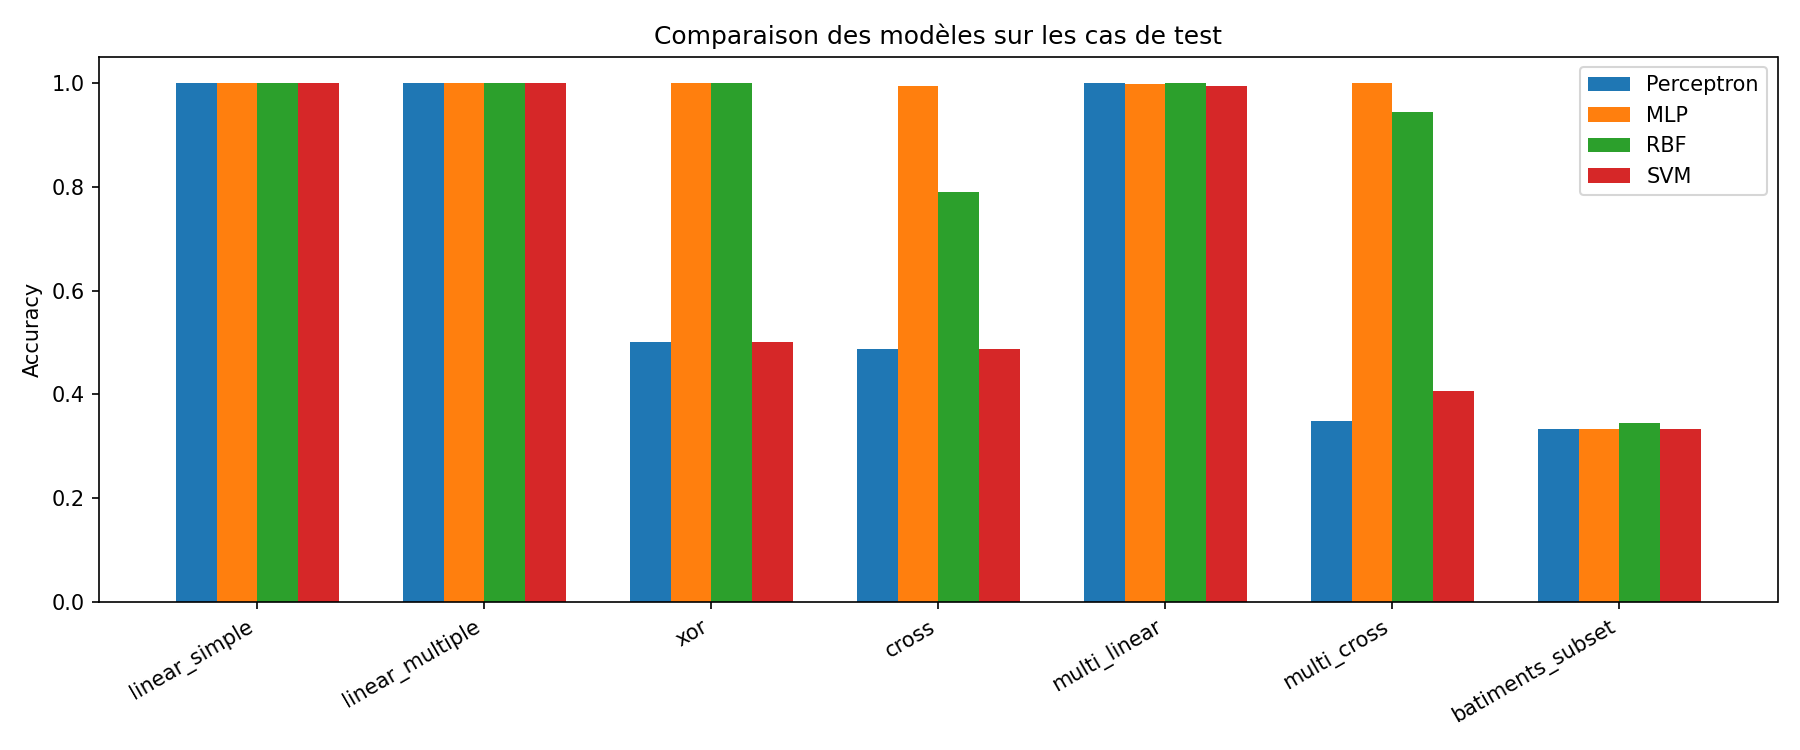

In [5]:
display(Image(filename=str(GRAPHS_DIR / "accuracy_cas_tests.png")))

## 5. Visualisation des points des cas de test

Les graphes suivants montrent les points avant prédiction. Chaque couleur correspond à une classe réelle.

Cette étape est importante, car elle permet de comprendre pourquoi certains modèles réussissent ou échouent.

Quand les points peuvent être séparés par une droite, un modèle linéaire peut fonctionner. Quand la séparation demande une courbe ou une zone plus complexe, les modèles non linéaires comme le MLP ou le RBF sont généralement plus adaptés.

points_linear_multiple.png


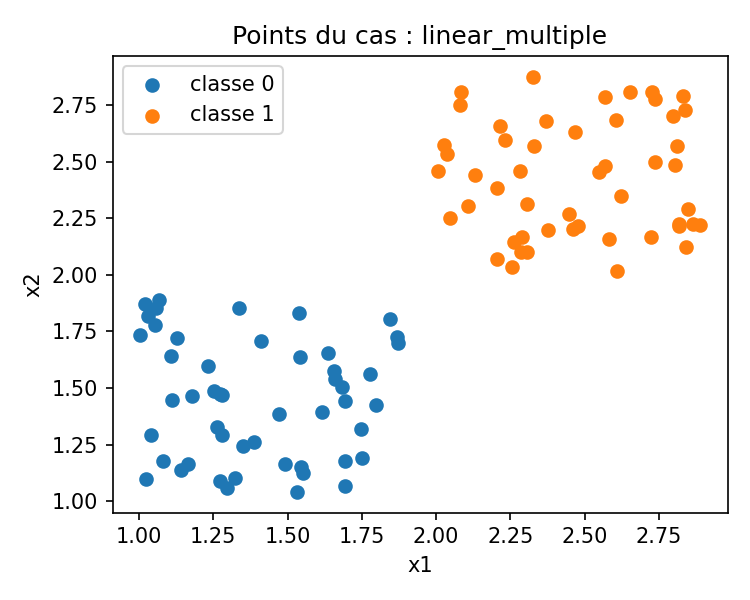

points_xor.png


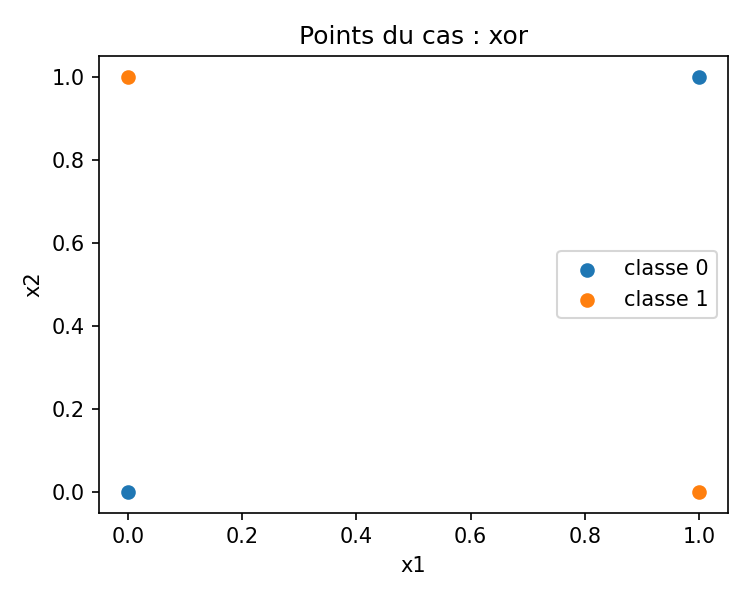

points_cross.png


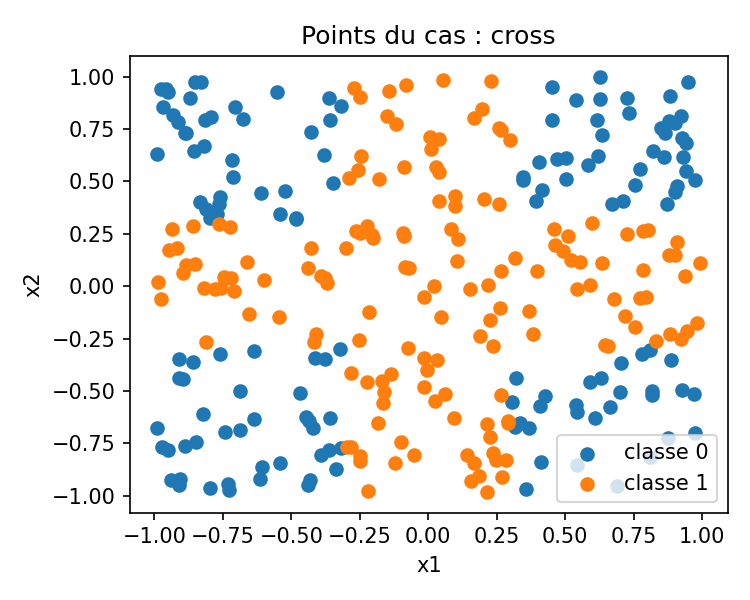

points_multi_cross.png


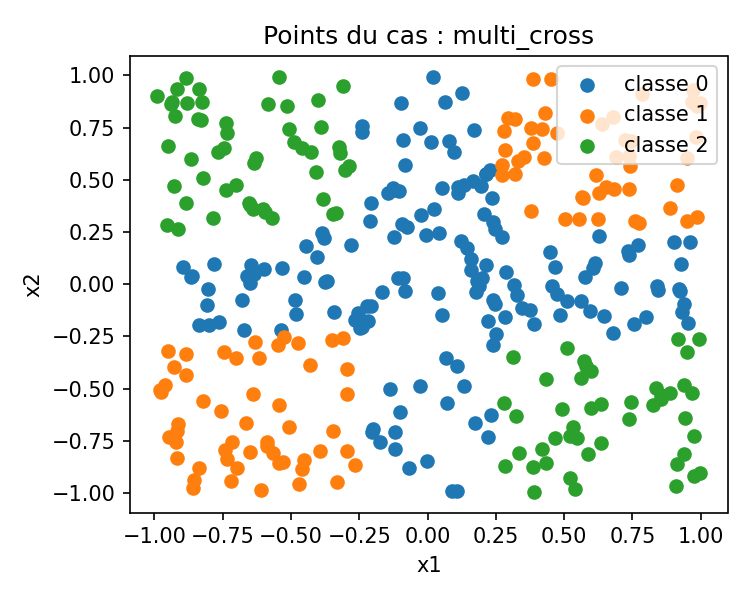

In [6]:
for name in ["points_linear_multiple.png", "points_xor.png", "points_cross.png", "points_multi_cross.png"]:
    print(name)
    display(Image(filename=str(GRAPHS_DIR / name)))

## 6. Exemples de prédictions

Les graphes suivants comparent les prédictions de certains modèles sur des cas non linéaires.

Les points bien classés et les erreurs sont visibles directement sur les figures. Cela rend la différence entre modèles plus facile à comprendre qu’un tableau seul.

Par exemple, le perceptron est un modèle linéaire. Il peut donc échouer sur XOR ou Cross, car ces problèmes ne peuvent pas être séparés correctement par une seule droite. Le MLP et le RBF peuvent créer des séparations plus souples, donc ils réussissent mieux sur ces cas.

prediction_xor_perceptron.png


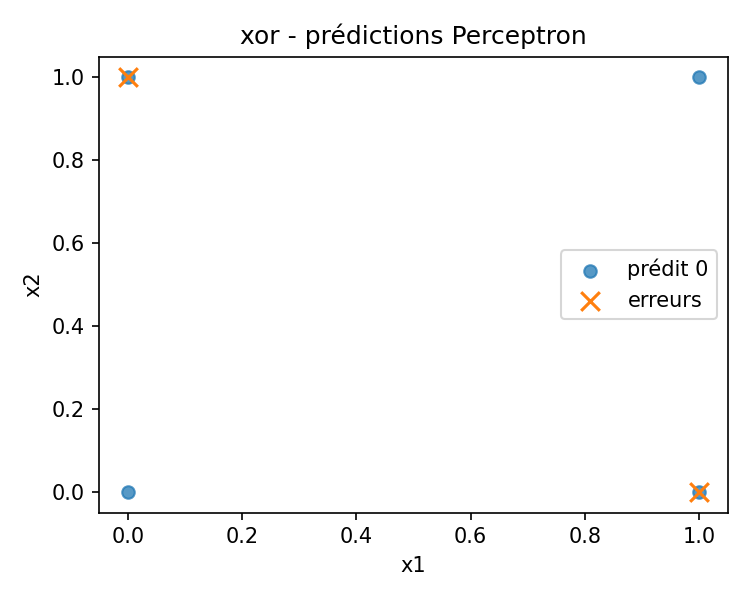

prediction_xor_mlp.png


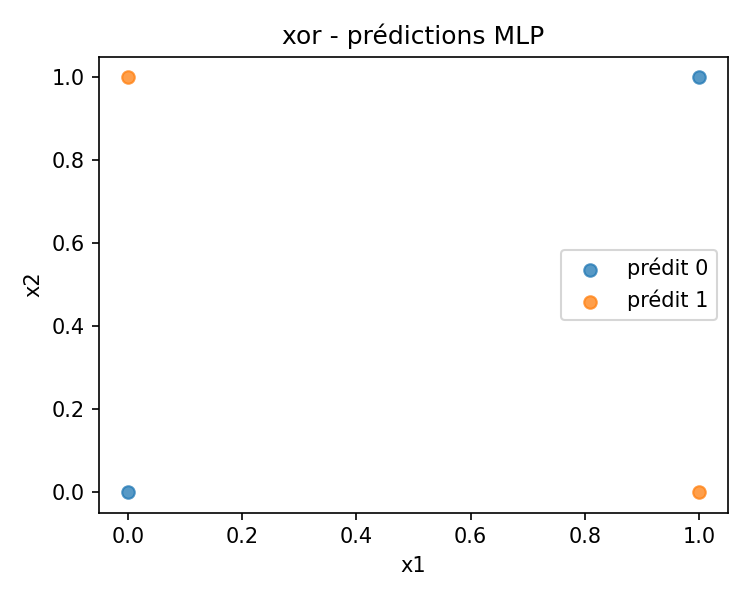

prediction_cross_perceptron.png


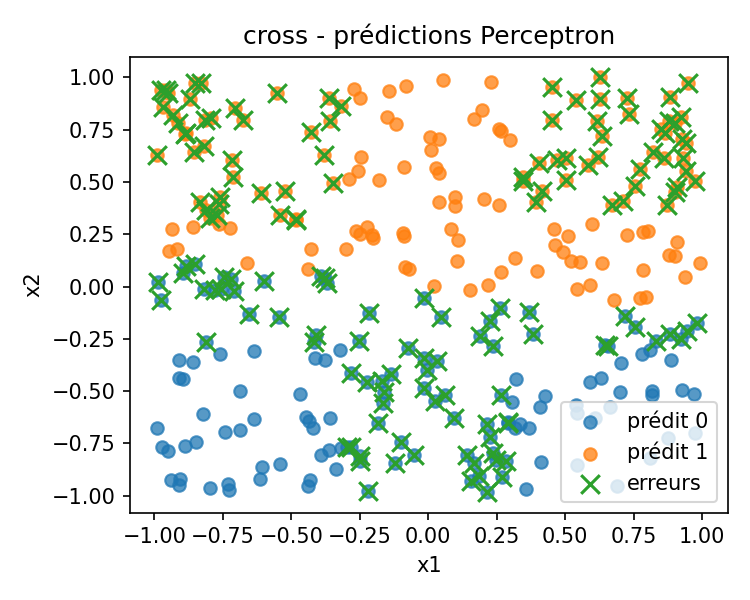

prediction_cross_mlp.png


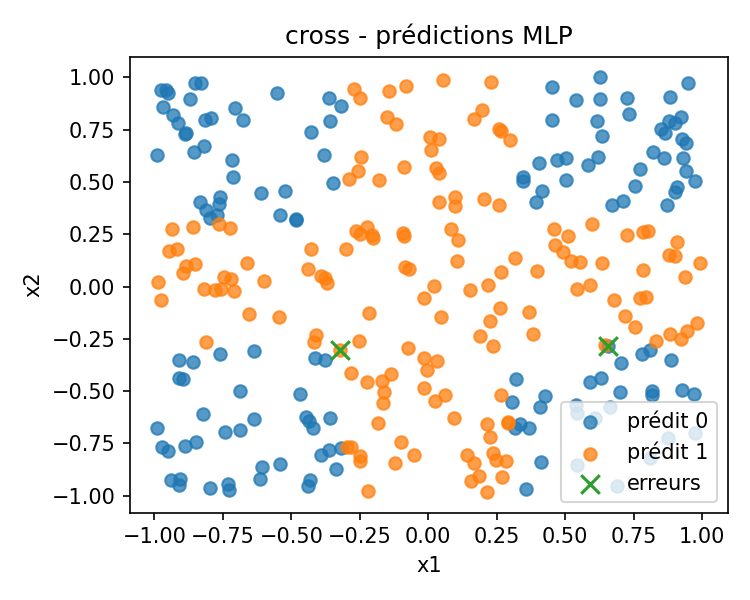

prediction_multi_cross_svm.png


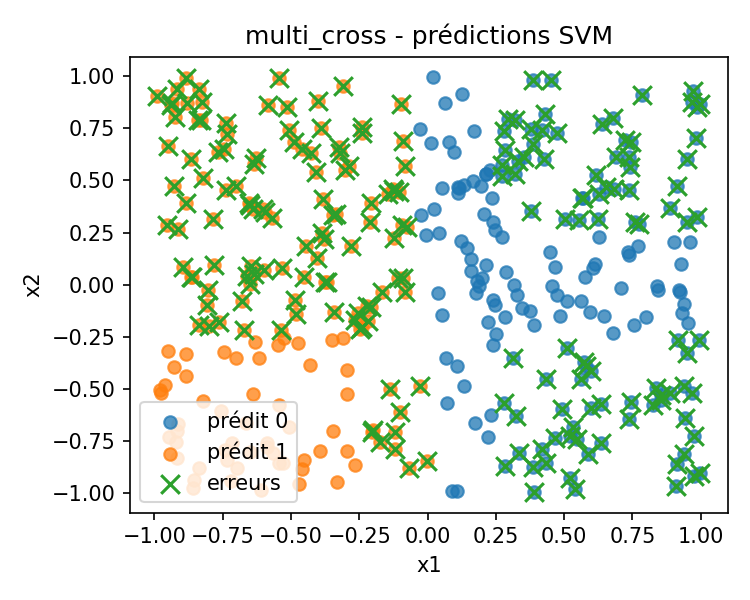

prediction_multi_cross_rbf.png


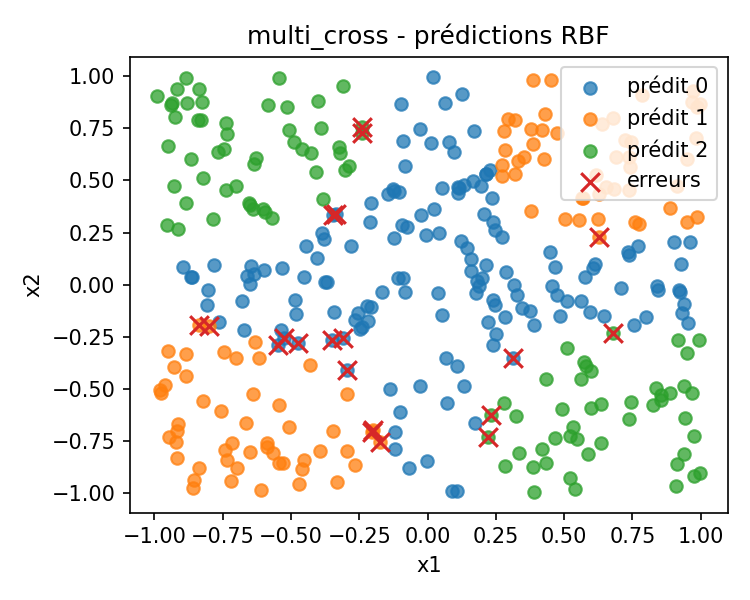

In [7]:
for name in ["prediction_xor_perceptron.png", "prediction_xor_mlp.png", "prediction_cross_perceptron.png", "prediction_cross_mlp.png", "prediction_multi_cross_svm.png", "prediction_multi_cross_rbf.png"]:
    print(name)
    display(Image(filename=str(GRAPHS_DIR / name)))

## 7. Courbes d’apprentissage

Les courbes d’apprentissage montrent l’évolution du modèle pendant l’entraînement.

Selon le modèle, la courbe représente une erreur ou une perte. L’idée générale reste la même :

- si la courbe descend, le modèle apprend progressivement ;
- si elle reste bloquée, le modèle n’arrive pas à améliorer sa séparation ;
- si elle descend rapidement puis se stabilise, le modèle a probablement trouvé une solution correcte.

La librairie fournit des historiques pour le perceptron, le MLP et le RBF. Le notebook trace donc ces courbes uniquement pour ces modèles. Aucune courbe artificielle n’est ajoutée pour le SVM.

history_xor_perceptron.png


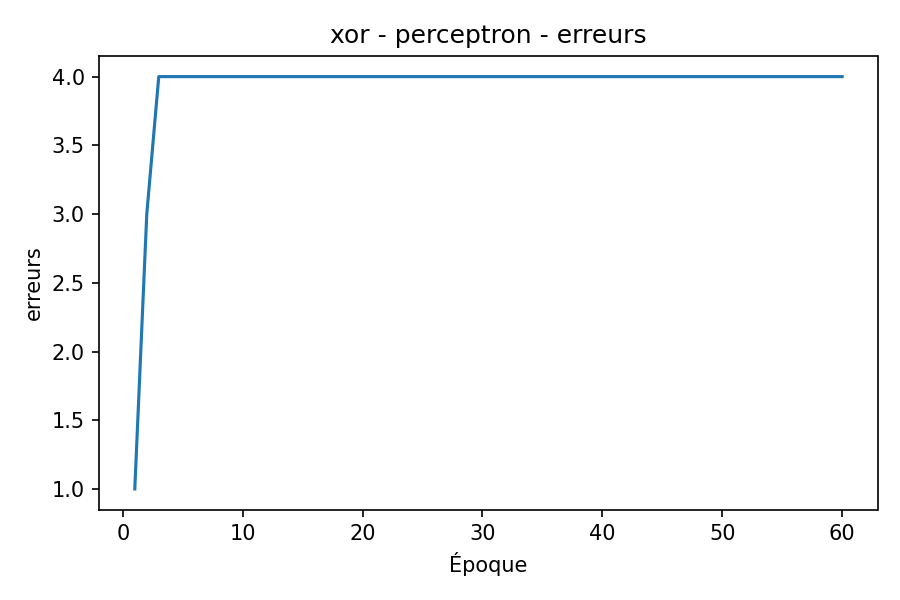

history_xor_mlp.png


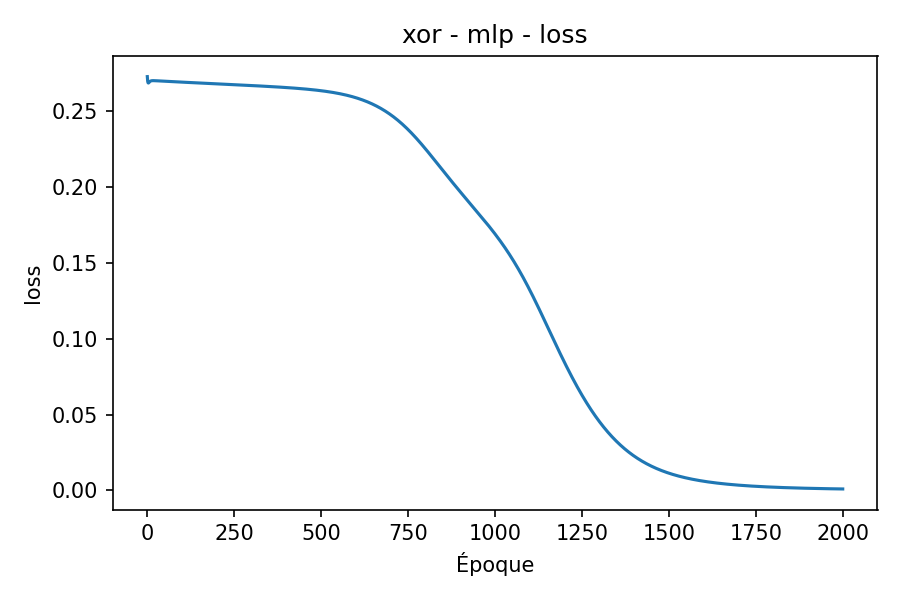

history_xor_rbf.png


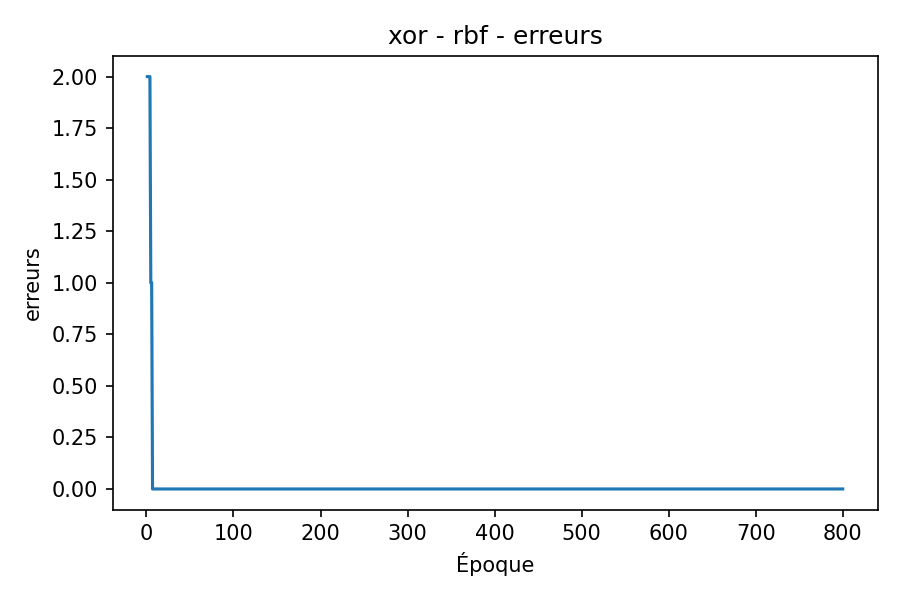

history_cross_mlp.png


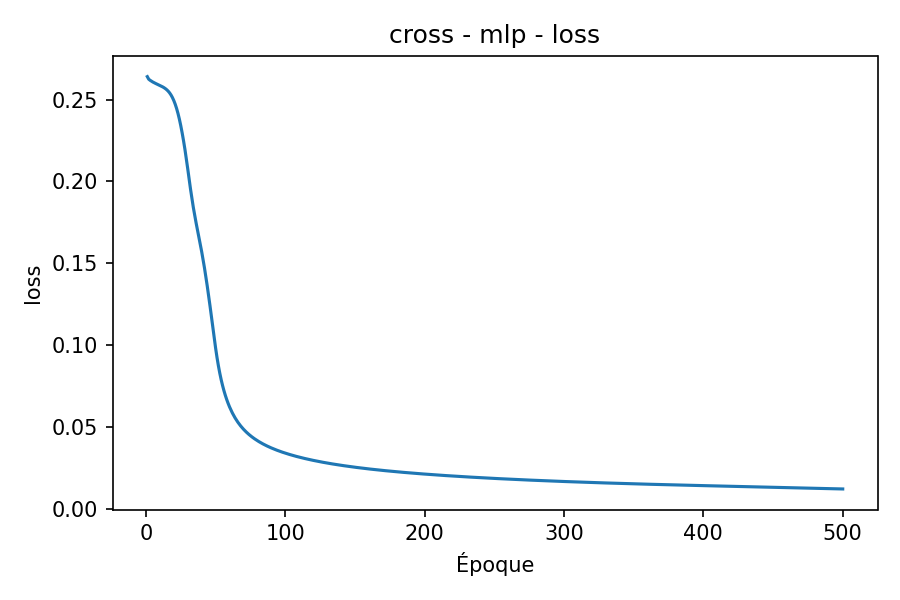

In [8]:
for name in ["history_xor_perceptron.png", "history_xor_mlp.png", "history_xor_rbf.png", "history_cross_mlp.png"]:
    print(name)
    display(Image(filename=str(GRAPHS_DIR / name)))

## 8. Application au dataset final de bâtiments

Le dataset final contient des images de bâtiments rangées par classe. Pour pouvoir les utiliser avec la librairie, les images sont converties en données numériques.

La préparation suit le principe suivant :

1. l’image est convertie en niveaux de gris ;
2. elle est redimensionnée ;
3. les pixels sont normalisés entre `0` et `1` ;
4. l’image est transformée en vecteur de valeurs ;
5. le label de la classe est ajouté à la fin de la ligne CSV.

Pour garder le notebook rapide et léger, un sous-échantillon équilibré du dataset final est utilisé. Les images sont réduites en `16 × 16`, ce qui donne `256` valeurs par image.

Ce test montre surtout que la librairie peut être appliquée au dataset réel du projet. Les scores peuvent rester limités, car les images sont très réduites et les modèles utilisés sont volontairement simples.

Art déco: 675 images dans le zip, 30 utilisees dans le notebook
Art nouveau: 990 images dans le zip, 30 utilisees dans le notebook
Gothique: 883 images dans le zip, 30 utilisees dans le notebook

Classes :
0,Art déco
1,Art nouveau
2,Gothique


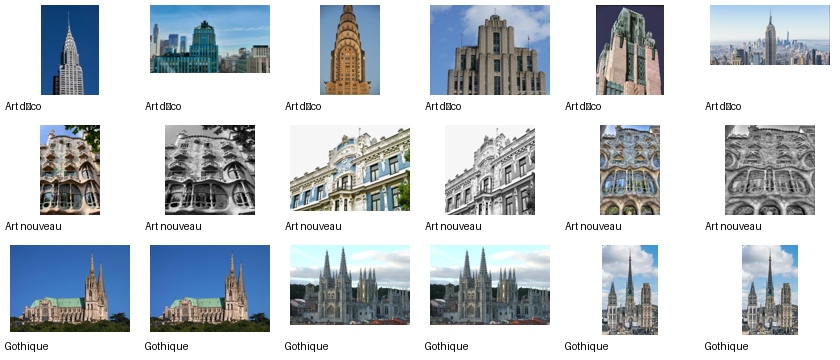

| Dataset | Modèle | Accuracy |
|---|---:|---:|
| batiments_subset | Perceptron | 0.333 |
| batiments_subset | MLP | 0.333 |
| batiments_subset | RBF | 0.344 |
| batiments_subset | SVM | 0.333 |

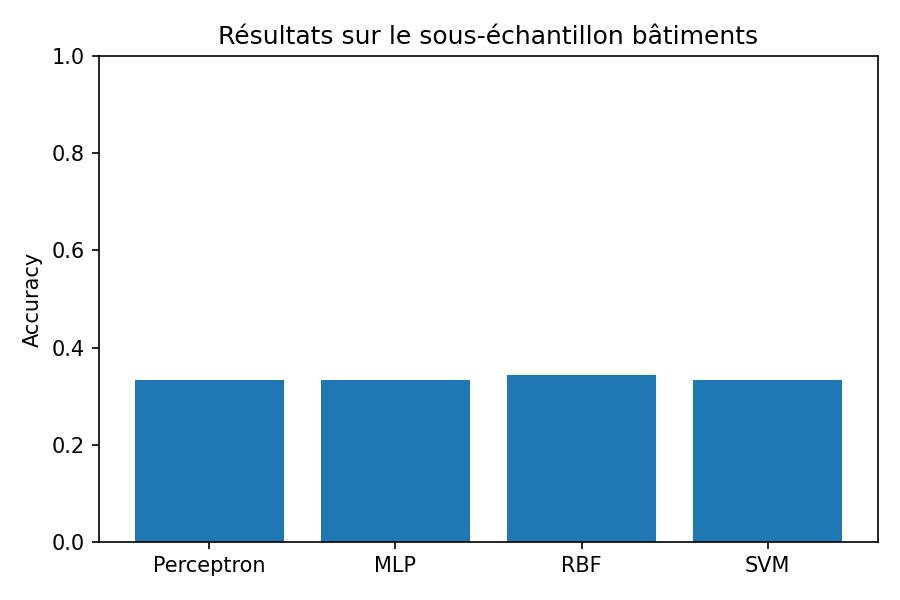

In [9]:
print((RESULTS_DIR / "dataset_summary.txt").read_text(encoding="utf-8"))
print("\nClasses :")
print((DATA_DIR / "batiments_classes.txt").read_text(encoding="utf-8"))

display(Image(filename=str(GRAPHS_DIR / "dataset_exemples_batiments.png")))

buildings_metrics = read_metrics(RESULTS_DIR / "metrics_buildings.csv")
lines = ["| Dataset | Modèle | Accuracy |", "|---|---:|---:|"]
for r in buildings_metrics:
    lines.append(f"| {r['case']} | {r['model']} | {r['accuracy']:.3f} |")
display(Markdown("\n".join(lines)))

display(Image(filename=str(GRAPHS_DIR / "accuracy_batiments_subset.png")))

### Lecture des résultats sur les bâtiments

Le dataset de bâtiments est plus difficile que les cas artificiels. Les images peuvent varier selon le cadrage, la lumière, la distance, l’angle de vue et les éléments présents autour du bâtiment.

En plus, les images utilisées ici sont fortement réduites. Une image en `16 × 16` garde seulement une information visuelle très simplifiée. Les résultats doivent donc être interprétés comme une première démonstration de fonctionnement, pas comme une performance finale maximale.

L’intérêt principal est de montrer que la même librairie peut passer des cas de test simples au dataset réel du projet.

## 9. Bilan de la démonstration

Ce notebook montre que la librairie C++ du projet peut être utilisée sur plusieurs types de données.

Les résultats principaux sont les suivants :

- les modèles linéaires fonctionnent bien sur les cas linéairement séparables ;
- le perceptron et le SVM linéaire sont limités sur les cas non linéaires comme XOR ou Cross ;
- le MLP et le RBF obtiennent de meilleurs résultats sur les formes non linéaires ;
- les cas multi-classes sont traités avec une stratégie un-contre-tous ;
- le dataset final de bâtiments est transformé en CSV puis utilisé par la librairie ;
- les graphes permettent de relier les résultats numériques à la forme réelle des données.

La démonstration reste volontairement pédagogique. Le but n’est pas d’obtenir un modèle industriel optimisé, mais de vérifier que les algorithmes étudiés sont implémentés, testés et appliqués à des données du projet.